<a href="https://colab.research.google.com/github/veronicaluzzi/Data-Science-Cohort-20/blob/main/Project-5/Project-5NLP_part1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing



This project will give you practical experience using Natural Language Processing techniques. This project is in three parts:
- in part 1) you will use a dataset in a CSV file
- in part 2) you will use the Wikipedia API to directly access content
on Wikipedia.
- in part 3) you will make your notebook interactive


### Part 1)



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



In [1]:
%%capture output
#install Wikipedia API
!pip3 install wikipedia-api

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

import time

import wikipediaapi

pd.options.display.max_columns = 100

import nltk
# nltk.download('omw-1.4')
nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [4]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n


     1	URI
     2	name
     3	text


In [5]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n


     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

In [6]:
# 1. Grab and read the CSV

url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv"
df = pd.read_csv(url)
df


,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...,...
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...


In [7]:
# Use .iloc[0] to grab the text of the person of interest (Gary Griffin)
# This looks at the 42630th row, and extracts whatever is in the 'text' column
griffin_full_text = df["text"].iloc[42630]

# Create a TextBlob of his full text profile
full_blob = TextBlob(griffin_full_text)
full_blob


TextBlob("gary griffin born october 26 1951 in cincinnati ohio is an american musician best known for performing as a keyboardist and vocalist with the beach boys brian wilson jan and dean and the surf city allstarsgriffin grew up in cincinnati and attended miami university and the university of cincinnati college conservatory of music where he majored in piano and music theoryin 1977 griffin moved to los angeles where he was hired as an organist by the beach boys joining them for the recording of their warner bros album miu griffin toured and recorded with jan and dean throughout the 80s and 90s and has appeared on several television shows most notably general hospital and full house in 2000 griffin served as music director for the emmynominated television miniseries the beach boys an american family for abc he also appeared in two roles in the film which was produced by john stamos griffin has produced an eclectic roster of artists most notably micky dolenz of the monkees and politic

In [8]:
# Extract the first 5 sentences using TextBlob's sentence tokenizer
# full_blob.sentences returns a list of sentence objects. [:5] gets the first five.
first_five_sentences_list = full_blob.sentences[:5]
first_five_sentences_list

[Sentence("gary griffin born october 26 1951 in cincinnati ohio is an american musician best known for performing as a keyboardist and vocalist with the beach boys brian wilson jan and dean and the surf city allstarsgriffin grew up in cincinnati and attended miami university and the university of cincinnati college conservatory of music where he majored in piano and music theoryin 1977 griffin moved to los angeles where he was hired as an organist by the beach boys joining them for the recording of their warner bros album miu griffin toured and recorded with jan and dean throughout the 80s and 90s and has appeared on several television shows most notably general hospital and full house in 2000 griffin served as music director for the emmynominated television miniseries the beach boys an american family for abc he also appeared in two roles in the film which was produced by john stamos griffin has produced an eclectic roster of artists most notably micky dolenz of the monkees and politi

In [9]:
len(first_five_sentences_list)

1

In [10]:
# Combine those 5 sentences back into a single text block
# We convert each sentence object to a string and join them with a space
five_sentence_string = " ".join([str(s) for s in first_five_sentences_list])
five_sentence_string

'gary griffin born october 26 1951 in cincinnati ohio is an american musician best known for performing as a keyboardist and vocalist with the beach boys brian wilson jan and dean and the surf city allstarsgriffin grew up in cincinnati and attended miami university and the university of cincinnati college conservatory of music where he majored in piano and music theoryin 1977 griffin moved to los angeles where he was hired as an organist by the beach boys joining them for the recording of their warner bros album miu griffin toured and recorded with jan and dean throughout the 80s and 90s and has appeared on several television shows most notably general hospital and full house in 2000 griffin served as music director for the emmynominated television miniseries the beach boys an american family for abc he also appeared in two roles in the film which was produced by john stamos griffin has produced an eclectic roster of artists most notably micky dolenz of the monkees and political satiri

In [11]:
# Create final target TextBlob out of just those 5 sentences
five_sentence_blob = TextBlob(five_sentence_string)

five_sentence_blob


TextBlob("gary griffin born october 26 1951 in cincinnati ohio is an american musician best known for performing as a keyboardist and vocalist with the beach boys brian wilson jan and dean and the surf city allstarsgriffin grew up in cincinnati and attended miami university and the university of cincinnati college conservatory of music where he majored in piano and music theoryin 1977 griffin moved to los angeles where he was hired as an organist by the beach boys joining them for the recording of their warner bros album miu griffin toured and recorded with jan and dean throughout the 80s and 90s and has appeared on several television shows most notably general hospital and full house in 2000 griffin served as music director for the emmynominated television miniseries the beach boys an american family for abc he also appeared in two roles in the film which was produced by john stamos griffin has produced an eclectic roster of artists most notably micky dolenz of the monkees and politic

In [12]:
size = len(full_blob)
size

1711

In [13]:
# convert the text for Gary Griffin into a string to be able to vectorize it. full_blob is a textblob.
full_blob_string = [str(s) for s in full_blob.sentences]
full_blob_string

['gary griffin born october 26 1951 in cincinnati ohio is an american musician best known for performing as a keyboardist and vocalist with the beach boys brian wilson jan and dean and the surf city allstarsgriffin grew up in cincinnati and attended miami university and the university of cincinnati college conservatory of music where he majored in piano and music theoryin 1977 griffin moved to los angeles where he was hired as an organist by the beach boys joining them for the recording of their warner bros album miu griffin toured and recorded with jan and dean throughout the 80s and 90s and has appeared on several television shows most notably general hospital and full house in 2000 griffin served as music director for the emmynominated television miniseries the beach boys an american family for abc he also appeared in two roles in the film which was produced by john stamos griffin has produced an eclectic roster of artists most notably micky dolenz of the monkees and political satir

In [14]:
size_1 = len(full_blob_string)
size_1

1

In [15]:
#vectorizing full_blob_string
vectorizer = CountVectorizer(stop_words="english")
bow_griffin = vectorizer.fit_transform(full_blob_string)

In [16]:
# to check the code above worked.
print("BoW Griffin Shape:", bow_griffin.shape)
print("Vocabulary Preview:", list(vectorizer.vocabulary_.keys())[:10])

BoW Griffin Shape: (1, 127)
Vocabulary Preview: ['gary', 'griffin', 'born', 'october', '26', '1951', 'cincinnati', 'ohio', 'american', 'musician']


In [17]:
# Make sure there are no missing values in the text column
# (CountVectorizer will error out if it encounters a NaN/Float value)
df['text'] = df["text"].fillna("")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [18]:
# Initialize the CountVectorizer
# stop_words='english' removes common filler words like 'the', 'is', 'and'
vectorizer = CountVectorizer(stop_words="english")

In [19]:
# Transform the entire text column straight into a Bag of Words matrix
# it works on all rows simultaneously!
bow_alltext = vectorizer.fit_transform(df["text"])

In [20]:
# --- VERIFY THE OUTPUT ---
print("--- VECTORIZATION COMPLETE ---")
print(f"Total number of people (rows): {bow_alltext.shape[0]}")
print(f"Total number of unique words (columns): {bow_alltext.shape[1]}")
print(f"Type of matrix generated: {type(bow_alltext)}")

--- VECTORIZATION COMPLETE ---
Total number of people (rows): 42786
Total number of unique words (columns): 437190
Type of matrix generated: <class 'scipy.sparse._csr.csr_matrix'>


In [21]:
# Transform BoW to TF-IDF
tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(bow_alltext)

# Fit your KNN model on the matrix
knn = NearestNeighbors(n_neighbors=11, metric="cosine")
knn.fit(tfidf_matrix)

NearestNeighbors(metric='cosine', n_neighbors=11)

In [22]:
distances, indices = knn.kneighbors(
  X = tfidf_matrix[42630],#reference cell
  n_neighbors = 11,# what are the 10 more close to it
)

In [23]:
indices

array([[42630,  2850, 33569,  5034,  1716,  4665, 36348, 10459, 26239,
        16970, 13115]])

In [24]:
distances

array([[0.        , 0.66875993, 0.70739112, 0.72445141, 0.73112111,
        0.73421783, 0.75153767, 0.75912665, 0.7618706 , 0.78103172,
        0.80559001]])

In [25]:
full_blob.sentiment

Sentiment(polarity=0.246875, subjectivity=0.396875)

In [26]:
import pandas as pd

# List of neighbor indices (including Gary Griffin and the 10 closest people)
neighbor_indices = [
    42630,
    2850,
    33569,
    5034,
    1716,
    4665,
    36348,
    10459,
    26239,
    16970,
    13115,
]

# Using .iloc extract names
# Use .copy() to ensure it's a completely independent, new DataFrame
df_closest = df.iloc[neighbor_indices].copy()

# Only keep the index and the 'name' column
# Reset the index to bring the original row numbers out into an explicit column
df_closest_names = df_closest[["name"]].reset_index().reset_index(names = ['rank'])
df_closest_names

,rank,index,name
0,0,42630,Gary Griffin (musician)
1,1,2850,Doug Griffin
2,2,33569,Tommy Brown (singer)
3,3,5034,Amanda Griffin
4,4,1716,Kathy Griffin
5,5,4665,Blake Griffin
6,6,36348,Nick Griffin
7,7,10459,Michael D. Griffin
8,8,26239,Kevin Griffin (basketball)
9,9,16970,Benjamin Griffin (alpine skier)


In [27]:
df_closest

,URI,name,text
42630,<http://dbpedia.org/resource/Gary_Griffin_(mus...,Gary Griffin (musician),gary griffin born october 26 1951 in cincinnat...
2850,<http://dbpedia.org/resource/Doug_Griffin>,Doug Griffin,douglas lee griffin born june 4 1947 is a form...
33569,<http://dbpedia.org/resource/Tommy_Brown_(sing...,Tommy Brown (singer),tommy brown born may 27 1931 atlanta georgia u...
5034,<http://dbpedia.org/resource/Amanda_Griffin>,Amanda Griffin,amanda griffin born amanda claire ricardo grif...
1716,<http://dbpedia.org/resource/Kathy_Griffin>,Kathy Griffin,kathleen mary kathy griffin born november 4 19...
4665,<http://dbpedia.org/resource/Blake_Griffin>,Blake Griffin,blake austin griffin born march 16 1989 is an ...
36348,<http://dbpedia.org/resource/Nick_Griffin>,Nick Griffin,nicholas john griffin born 1 march 1959 is a f...
10459,<http://dbpedia.org/resource/Michael_D._Griffin>,Michael D. Griffin,for other people with the same name see michae...
26239,<http://dbpedia.org/resource/Kevin_Griffin_(ba...,Kevin Griffin (basketball),kevin griffin born june 3 1975 in mississippi ...
16970,<http://dbpedia.org/resource/Benjamin_Griffin_...,Benjamin Griffin (alpine skier),benjamin griffin born 22 september 1986 is an ...


### Part 2)



- For the same reference person that you chose in Part 1), use the Wikipedia API to access the whole content of the reference person's Wikipedia page.
- The goal of Part 2) is to ...
  1. Print out the text of the Wikipedia article for the reference person
  1. Determine the sentiment of the text of the Wikipedia page for the reference person
  1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)
  1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
  1. Compare, i.e. plot,  the nearest ranking from Step 1) with the Wikipedia page nearness ranking.  A difference of the rank is one means of comparison.



In [28]:
%%capture
!pip3 install wikipedia-api

In [29]:
import wikipediaapi

In [30]:
df_closest['name'].iloc[0]

'Gary Griffin (musician)'

In [31]:
# https://en.wikipedia.org/wiki/Gary_Griffin_(musician)
# target = 'Gary_Griffin (musician)'
target = df_closest['name'].iloc[0]
wikip = wikipediaapi.Wikipedia('interest')
page_ex = wikip.page(target)
target_text = page_ex.text
target_text

'Gary Griffin (born October 26, 1951, in Cincinnati, Ohio) is an American musician, best known for performing as a keyboardist and vocalist with The Beach Boys, Brian Wilson, Jan and Dean and The Surf City Allstars.\n\nEarly career\nGriffin grew up in Cincinnati and attended Miami University and the University of Cincinnati – College-Conservatory of Music, where he majored in piano and music theory.\nIn 1977, Griffin moved to Los Angeles where he was hired as an organist by The Beach Boys, joining them for the recording of their Warner Brothers album M.I.U., as well as several other related productions, Almost Summer by spin-off group Celebration and Weavings by jazz saxophonist Charles Lloyd.\nGriffin toured and recorded with Jan and Dean throughout the 1980s and 1990s, and has appeared as a regular on several television shows, most notably General Hospital and Full House. In 2000, Griffin served as music director, alongside producer John Stamos, for the Emmy-nominated television mini

In [32]:
# clean the text, and create a textblob
target_text_clean = (
  target_text
  .lower()
  .replace("\n"," ")
  .replace("\'s",'')
  .replace('\'','')
  .replace("(", "")
  .replace(")", "")
  .replace('"', "")
)
target_text_clean = target_text
target_text_clean

'Gary Griffin (born October 26, 1951, in Cincinnati, Ohio) is an American musician, best known for performing as a keyboardist and vocalist with The Beach Boys, Brian Wilson, Jan and Dean and The Surf City Allstars.\n\nEarly career\nGriffin grew up in Cincinnati and attended Miami University and the University of Cincinnati – College-Conservatory of Music, where he majored in piano and music theory.\nIn 1977, Griffin moved to Los Angeles where he was hired as an organist by The Beach Boys, joining them for the recording of their Warner Brothers album M.I.U., as well as several other related productions, Almost Summer by spin-off group Celebration and Weavings by jazz saxophonist Charles Lloyd.\nGriffin toured and recorded with Jan and Dean throughout the 1980s and 1990s, and has appeared as a regular on several television shows, most notably General Hospital and Full House. In 2000, Griffin served as music director, alongside producer John Stamos, for the Emmy-nominated television mini

In [33]:
# create the TextBlob
w_blob = TextBlob(target_text_clean)
w_blob

TextBlob("Gary Griffin (born October 26, 1951, in Cincinnati, Ohio) is an American musician, best known for performing as a keyboardist and vocalist with The Beach Boys, Brian Wilson, Jan and Dean and The Surf City Allstars.

Early career
Griffin grew up in Cincinnati and attended Miami University and the University of Cincinnati – College-Conservatory of Music, where he majored in piano and music theory.
In 1977, Griffin moved to Los Angeles where he was hired as an organist by The Beach Boys, joining them for the recording of their Warner Brothers album M.I.U., as well as several other related productions, Almost Summer by spin-off group Celebration and Weavings by jazz saxophonist Charles Lloyd.
Griffin toured and recorded with Jan and Dean throughout the 1980s and 1990s, and has appeared as a regular on several television shows, most notably General Hospital and Full House. In 2000, Griffin served as music director, alongside producer John Stamos, for the Emmy-nominated television 

In [34]:
# determine the sentiment for GG for the article in Wikipedia
w_blob.sentiment

Sentiment(polarity=0.18712910353535353, subjectivity=0.40941506410256406)

Sentiment(polarity=0.246875, subjectivity=0.396875)

In [35]:
# df_closest_names = closest names from Part 1
# Create an empty list to store the scraped texts


In [36]:
# to remove GG from the df from Part 1, 10-row DataFrame containing only the neighbors
# df_neighbors_only = df_closest_names.drop(index=0).reset_index(drop=True)
df_neighbors_only = df_closest_names.reset_index(drop=True)
df_neighbors_only

,rank,index,name
0,0,42630,Gary Griffin (musician)
1,1,2850,Doug Griffin
2,2,33569,Tommy Brown (singer)
3,3,5034,Amanda Griffin
4,4,1716,Kathy Griffin
5,5,4665,Blake Griffin
6,6,36348,Nick Griffin
7,7,10459,Michael D. Griffin
8,8,26239,Kevin Griffin (basketball)
9,9,16970,Benjamin Griffin (alpine skier)


In [37]:
# create a for loop to through the column 'name' on the df listing all closest names
scraped_texts = [target_text_clean]
for index, row in df_neighbors_only.iloc[1:].iterrows():
    name = row["name"]

    # Request the specific page from Wikipedia
    page = wikip.page(name)
    # Check if the page actually exists
    if page.exists():
        print(f"Success: Found and collecting text for '{name}'...")
        # page.summary gets just the introduction, page.text gets the FULL article text
        scraped_texts.append(page.text)
    else:
        print(f"Warning: Could not find an exact Wikipedia page for '{name}'")
        scraped_texts.append("Page not found on Wikipedia")

    # Pause for 0.5 seconds between requests
    # This prevents your script from slamming Wikipedia's servers too hard
    time.sleep(0.5)

Success: Found and collecting text for 'Doug Griffin'...
Success: Found and collecting text for 'Tommy Brown (singer)'...
Success: Found and collecting text for 'Amanda Griffin'...
Success: Found and collecting text for 'Kathy Griffin'...
Success: Found and collecting text for 'Blake Griffin'...
Success: Found and collecting text for 'Nick Griffin'...
Success: Found and collecting text for 'Michael D. Griffin'...
Success: Found and collecting text for 'Kevin Griffin (basketball)'...
Success: Found and collecting text for 'Benjamin Griffin (alpine skier)'...
Success: Found and collecting text for 'John Cowsill'...


In [38]:
df_neighbors_only["Full_Wikipedia_Text"] = scraped_texts

print("\n--- COLLECTION COMPLETE ---")
print(df_neighbors_only.head(3))


--- COLLECTION COMPLETE ---
   rank  index                     name  \
0     0  42630  Gary Griffin (musician)   
1     1   2850             Doug Griffin   
2     2  33569     Tommy Brown (singer)   

                                 Full_Wikipedia_Text  
0  Gary Griffin (born October 26, 1951, in Cincin...  
1  Douglas Lee Griffin (June 4, 1947 – July 27, 2...  
2  Thomas A. Brown (May 27, 1931 – March 12, 2016...  


In [39]:
df_neighbors_only

,rank,index,name,Full_Wikipedia_Text
0,0,42630,Gary Griffin (musician),"Gary Griffin (born October 26, 1951, in Cincin..."
1,1,2850,Doug Griffin,"Douglas Lee Griffin (June 4, 1947 – July 27, 2..."
2,2,33569,Tommy Brown (singer),"Thomas A. Brown (May 27, 1931 – March 12, 2016..."
3,3,5034,Amanda Griffin,Amanda Claire Ricardo Griffin (born 28 Septemb...
4,4,1716,Kathy Griffin,"Kathleen Mary Griffin (born November 4, 1960) ..."
5,5,4665,Blake Griffin,"Blake Austin Griffin (born March 16, 1989) is ..."
6,6,36348,Nick Griffin,Nicholas John Griffin (born 1 March 1959) is a...
7,7,10459,Michael D. Griffin,"Michael Douglas Griffin (born November 1, 1949..."
8,8,26239,Kevin Griffin (basketball),Kevin Griffin Jr. is an American professional ...
9,9,16970,Benjamin Griffin (alpine skier),"Benjamin Griffin (born 22 September 1986), als..."


In [40]:
tf_idf_matrix = TfidfVectorizer(stop_words = 'english')
tf_idf = tf_idf_matrix.fit_transform(df_neighbors_only['Full_Wikipedia_Text'])
tf_idf


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6317 stored elements and shape (11, 4360)>

In [41]:
tf_idf[:, :10].todense()

matrix([[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.0330722 , 0.0330722 , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.03646302],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.01608852, 0.        , 0.        , 0.01070118, 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.00589918],
        [0.0280689 , 0.        , 0.        , 0.        , 0.00533425,
         0.00533425, 0.0106685 , 0.        , 0.00533425, 0.09997968],
        [0.01172823, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.00780097, 0.        , 0.00860078],
        [0.        , 0.    

In [42]:
nn = NearestNeighbors().fit(tf_idf)

In [43]:
distances, indices = nn.kneighbors(
  X = tf_idf[0],#reference cell
  n_neighbors = 11,# what are the 10 more close to it
)

In [44]:
distances

array([[0.        , 1.21785113, 1.24206496, 1.32891805, 1.33052967,
        1.33362622, 1.34709601, 1.34749326, 1.34934906, 1.35677508,
        1.36407422]])

In [45]:
indices

array([[ 0, 10,  4,  2,  6,  5,  7,  1,  3,  8,  9]])

In [46]:
rank_df = df_neighbors_only.iloc[indices[0]].reset_index(drop = True).reset_index(names = ['wiki_rank'])
rank_df

,wiki_rank,rank,index,name,Full_Wikipedia_Text
0,0,0,42630,Gary Griffin (musician),"Gary Griffin (born October 26, 1951, in Cincin..."
1,1,10,13115,John Cowsill,"John Patrick Cowsill (born March 2, 1956) is a..."
2,2,4,1716,Kathy Griffin,"Kathleen Mary Griffin (born November 4, 1960) ..."
3,3,2,33569,Tommy Brown (singer),"Thomas A. Brown (May 27, 1931 – March 12, 2016..."
4,4,6,36348,Nick Griffin,Nicholas John Griffin (born 1 March 1959) is a...
5,5,5,4665,Blake Griffin,"Blake Austin Griffin (born March 16, 1989) is ..."
6,6,7,10459,Michael D. Griffin,"Michael Douglas Griffin (born November 1, 1949..."
7,7,1,2850,Doug Griffin,"Douglas Lee Griffin (June 4, 1947 – July 27, 2..."
8,8,3,5034,Amanda Griffin,Amanda Claire Ricardo Griffin (born 28 Septemb...
9,9,8,26239,Kevin Griffin (basketball),Kevin Griffin Jr. is an American professional ...


In [47]:
rank_df['delta'] = rank_df['rank']- rank_df['wiki_rank']
rank_df

,wiki_rank,rank,index,name,Full_Wikipedia_Text,delta
0,0,0,42630,Gary Griffin (musician),"Gary Griffin (born October 26, 1951, in Cincin...",0
1,1,10,13115,John Cowsill,"John Patrick Cowsill (born March 2, 1956) is a...",9
2,2,4,1716,Kathy Griffin,"Kathleen Mary Griffin (born November 4, 1960) ...",2
3,3,2,33569,Tommy Brown (singer),"Thomas A. Brown (May 27, 1931 – March 12, 2016...",-1
4,4,6,36348,Nick Griffin,Nicholas John Griffin (born 1 March 1959) is a...,2
5,5,5,4665,Blake Griffin,"Blake Austin Griffin (born March 16, 1989) is ...",0
6,6,7,10459,Michael D. Griffin,"Michael Douglas Griffin (born November 1, 1949...",1
7,7,1,2850,Doug Griffin,"Douglas Lee Griffin (June 4, 1947 – July 27, 2...",-6
8,8,3,5034,Amanda Griffin,Amanda Claire Ricardo Griffin (born 28 Septemb...,-5
9,9,8,26239,Kevin Griffin (basketball),Kevin Griffin Jr. is an American professional ...,-1


Compare, i.e. plot, the nearest ranking from Step 1) with the Wikipedia page nearness ranking. A difference of the rank is one means of comparison.

<Axes: ylabel='name'>

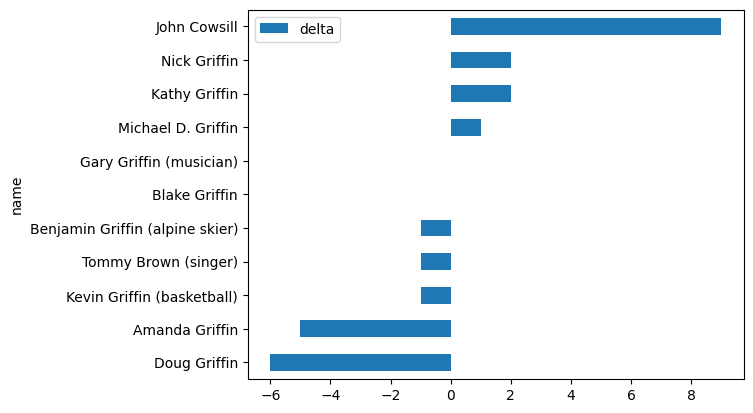

In [48]:
rank_df.sort_values(by = 'delta').plot(kind = 'barh', x ='name', y = 'delta')

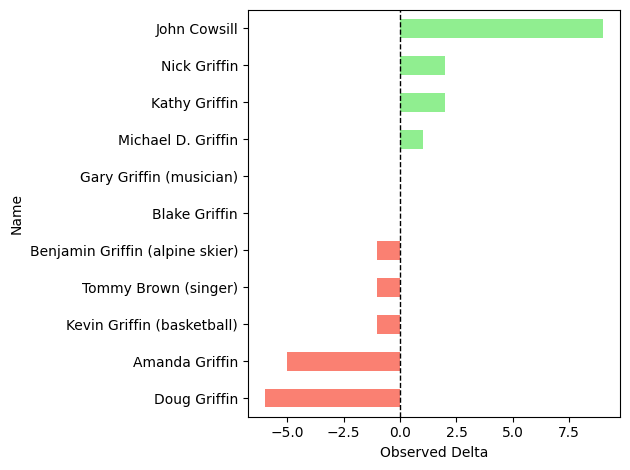

In [49]:
# 1. Sort your DataFrame
sorted_df = rank_df.sort_values(by='delta')

# This creates a list: 'salmon' if the delta is negative, 'lightgreen' if positive
colors = ['salmon' if val < 0 else 'lightgreen' for val in sorted_df['delta']]

# 3. Plot and pass the 'colors' list into the color parameter
ax = sorted_df.plot(
    kind='barh',
    x='name',
    y='delta',
    color=colors,  # <--- Use the dynamic list here instead of the hardcoded list
    legend=False
)

# 4. Add your customizations and save
ax.axvline(x=0, color='black', linestyle='--', lw=1)
ax.set_xlabel('Observed Delta')
ax.set_ylabel('Name')
plt.tight_layout()

# 5. Save and show
plt.savefig('knn_wikipedia_delta.png', bbox_inches='tight', dpi=300)
plt.show()

### Part 3)


Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.
